### Imports

In [2]:
from pathlib import Path
import os
import random

os.environ.setdefault("MPLCONFIGDIR", str((Path.cwd() / ".matplotlib_cache").resolve()))
os.environ.setdefault("XDG_CACHE_HOME", str((Path.cwd() / ".cache").resolve()))
(Path.cwd() / ".matplotlib_cache").mkdir(exist_ok=True)
(Path.cwd() / ".cache").mkdir(exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def find_data_dir() -> Path:
    env_path = os.environ.get("CHEST_XRAY_DIR")
    candidates = []

    if env_path:
        candidates.append(Path(env_path).expanduser())

    candidates.extend(
        [
            Path("chest_xray"),
            Path.cwd() / "chest_xray",
            Path.cwd().parent / "chest_xray",
            Path.cwd() / "DeepLearning" / "chest_xray",
            Path.cwd().parent / "DeepLearning" / "chest_xray",
            Path.home() / "ComputerVisionPneumonia" / "chest_xray",
        ]
    )

    checked = []
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in checked:
            continue
        checked.append(candidate)
        if (candidate / "train").exists() and (candidate / "test").exists():
            return candidate

    checked_paths = "\n".join(f"- {path}" for path in checked)
    raise FileNotFoundError(
        "Dataset chest_xray não encontrado. Coloque a pasta chest_xray na raiz "
        "do projeto ou dentro de DeepLearning, ou defina CHEST_XRAY_DIR com o "
        f"caminho completo. Locais verificados:\n{checked_paths}"
    )


DATA_DIR = find_data_dir()
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"
AUGMENTED_DIR = DATA_DIR / "train_augmented"
IMAGE_EXTENSIONS = {".jpeg", ".jpg", ".png", ".bmp"}

print("TensorFlow:", tf.__version__)
print("Treino:", TRAIN_DIR.resolve())
print("Teste:", TEST_DIR.resolve())


TensorFlow: 2.21.0
Treino: /Users/antonio/ComputerVisionPneumonia/chest_xray/train
Teste: /Users/antonio/ComputerVisionPneumonia/chest_xray/test


### Transformações e Carregamento de Dados

In [3]:
def label_from_folder(folder_name: str) -> int:
    if folder_name == "NORMAL":
        return 0
    if folder_name.startswith("PNEUMONIA"):
        return 1
    raise ValueError(f"Classe desconhecida: {folder_name}")


def list_images(directory: Path):
    return sorted(
        path
        for path in directory.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )


def build_original_dataframe(split_dir: Path) -> pd.DataFrame:
    rows = []
    for class_dir in sorted(path for path in split_dir.iterdir() if path.is_dir()):
        for image_path in list_images(class_dir):
            rows.append(
                {
                    "path": str(image_path),
                    "label": label_from_folder(class_dir.name),
                    "class_name": (
                        "Normal" if class_dir.name == "NORMAL" else "Pneumonia"
                    ),
                    "subclass": class_dir.name,
                    "source_type": "original",
                    "source_path": str(image_path),
                }
            )
    return pd.DataFrame(rows)


original_train_df = build_original_dataframe(TRAIN_DIR)
test_df = build_original_dataframe(TEST_DIR)

display(
    original_train_df["class_name"]
    .value_counts()
    .rename_axis("classe")
    .reset_index(name="quantidade")
)
display(
    test_df["class_name"]
    .value_counts()
    .rename_axis("classe")
    .reset_index(name="quantidade")
)


,classe,quantidade
0,Pneumonia,3883
1,Normal,1349


,classe,quantidade
0,Pneumonia,390
1,Normal,234


### Separação entre Treino e Validação

In [4]:
train_base_df, val_df = train_test_split(
    original_train_df,
    test_size=0.20,
    random_state=SEED,
    stratify=original_train_df["label"],
)

train_base_df = train_base_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

train_source_paths = set(train_base_df["source_path"])
augmented_manifest = AUGMENTED_DIR / "manifest.csv"

if augmented_manifest.exists():
    aug_df = pd.read_csv(augmented_manifest)
    aug_df = aug_df.rename(columns={"output_path": "path"})
    aug_df["label"] = 0
    aug_df["class_name"] = "Normal"
    aug_df["subclass"] = "NORMAL"
    aug_df["source_type"] = "augmented"
    aug_df = aug_df[
        ["path", "label", "class_name", "subclass", "source_type", "source_path"]
    ]
    aug_df = aug_df[aug_df["source_path"].isin(train_source_paths)].reset_index(
        drop=True
    )
else:
    aug_df = pd.DataFrame(columns=train_base_df.columns)

train_df = pd.concat([train_base_df, aug_df], ignore_index=True)

print(f"Treino original após split: {len(train_base_df)}")
print(f"Validação original: {len(val_df)}")
print(f"Augmentações NORMAL usadas no treino: {len(aug_df)}")
print(f"Treino final: {len(train_df)}")

display(
    train_df["class_name"]
    .value_counts()
    .rename_axis("classe")
    .reset_index(name="quantidade_treino")
)
display(
    val_df["class_name"]
    .value_counts()
    .rename_axis("classe")
    .reset_index(name="quantidade_validacao")
)


Treino original após split: 4185
Validação original: 1047
Augmentações NORMAL usadas no treino: 0
Treino final: 4185


,classe,quantidade_treino
0,Pneumonia,3106
1,Normal,1079


,classe,quantidade_validacao
0,Pneumonia,777
1,Normal,270


### Cálculo de Pesos das Classes

In [5]:
classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].to_numpy(),
)
class_weight = {
    int(class_id): float(weight) for class_id, weight in zip(classes, weights)
}
class_weight


{0: 1.9392956441149212, 1: 0.6736960721184804}

### Pipeline tf.data

In [6]:
def load_and_preprocess(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.cast(label, tf.float32)
    return image, label


def make_dataset(dataframe: pd.DataFrame, training: bool) -> tf.data.Dataset:
    paths = dataframe["path"].astype(str).to_numpy()
    labels = dataframe["label"].astype("float32").to_numpy()
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True
        )
    dataset = dataset.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset


train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

train_ds


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>

In [7]:
images, labels = next(iter(train_ds))
print("Batch de imagens:", images.shape)
print("Batch de labels:", labels.shape)
print("Pixel mínimo:", float(tf.reduce_min(images)))
print("Pixel máximo:", float(tf.reduce_max(images)))


Batch de imagens: (32, 224, 224, 3)
Batch de labels: (32,)
Pixel mínimo: 0.0
Pixel máximo: 1.0


### Inspeção Visual das Amostras

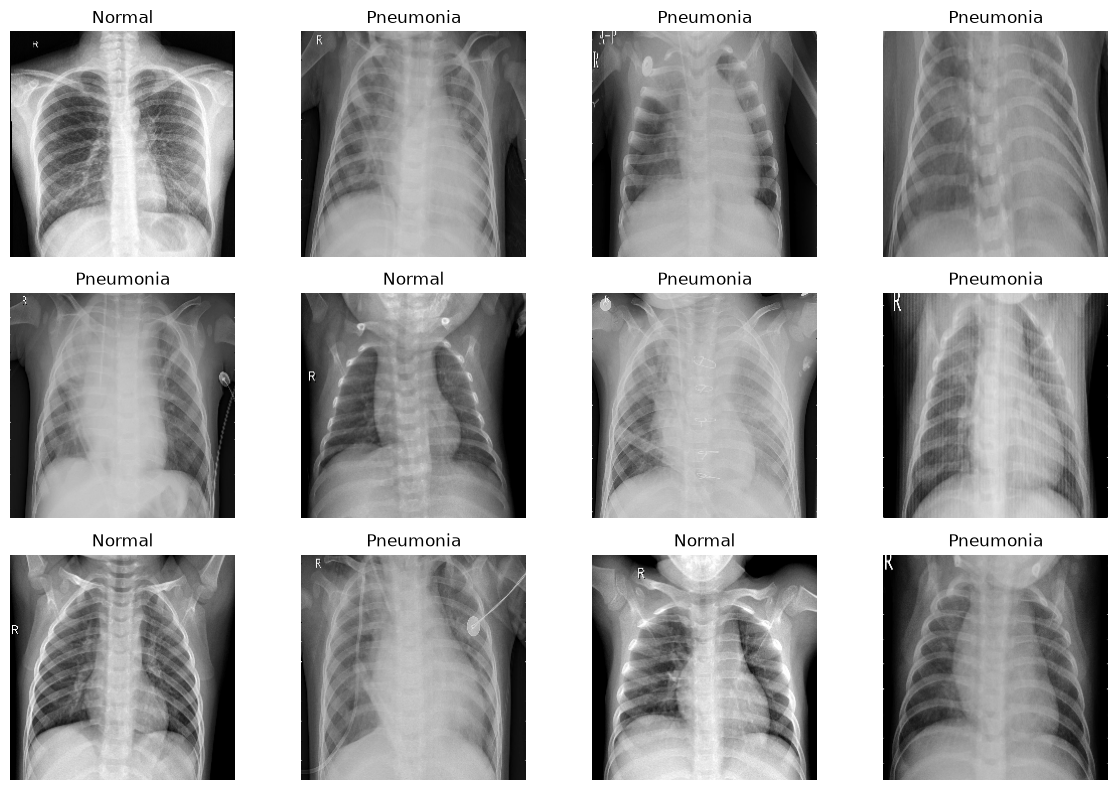

In [8]:
class_names = {0: "Normal", 1: "Pneumonia"}

plt.figure(figsize=(12, 8))
for index in range(12):
    ax = plt.subplot(3, 4, index + 1)
    plt.imshow(images[index].numpy())
    plt.title(class_names[int(labels[index].numpy())])
    plt.axis("off")
plt.tight_layout()
plt.show()


### Construção do Modelo Inicial

In [9]:
augmentation_layers = [
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomZoom(0.05),
    tf.keras.layers.RandomContrast(0.10),
]

if hasattr(tf.keras.layers, "RandomBrightness"):
    try:
        augmentation_layers.append(
            tf.keras.layers.RandomBrightness(0.08, value_range=(0, 1))
        )
    except TypeError:
        augmentation_layers.append(tf.keras.layers.RandomBrightness(0.08))

data_augmentation = tf.keras.Sequential(augmentation_layers, name="augmentacao_treino")

inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
x = data_augmentation(inputs)
x = tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same")(x)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Conv2D(128, 3, activation="relu", padding="same")(x)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.30)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentacao_treino (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,377 (364.75 KB)

 Trainable params: 93,377 (364.75 KB)

 Non-trainable params: 0 (0.00 B)

### Loop de Treinamento e Validação

In [10]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True,
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight,
    callbacks=callbacks,
)


Epoch 1/10


/Users/antonio/VisaoComputacional/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


131/131 ━━━━━━━━━━━━━━━━━━━━ 244s 2s/step - accuracy: 0.3842 - auc: 0.5403 - loss: 0.6908 - precision: 0.7580 - recall: 0.2502 - val_accuracy: 0.5511 - val_auc: 0.8549 - val_loss: 0.6883 - val_precision: 0.9968 - val_recall: 0.3964
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 234s 2s/step - accuracy: 0.5599 - auc: 0.5636 - loss: 0.6872 - precision: 0.7806 - recall: 0.5660 - val_accuracy: 0.6275 - val_auc: 0.8173 - val_loss: 0.6884 - val_precision: 0.9801 - val_recall: 0.5084
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.6215 - auc: 0.6691 - loss: 0.6546 - precision: 0.8208 - recall: 0.6269 - val_accuracy: 0.7469 - val_auc: 0.9343 - val_loss: 0.5539 - val_precision: 0.9885 - val_recall: 0.6667
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 119s 904ms/step - accuracy: 0.7668 - auc: 0.8397 - loss: 0.5216 - precision: 0.8986 - recall: 0.7730 - val_accuracy: 0.6361 - val_auc: 0.8913 - val_loss: 0.6877 - val_precision: 0.9877 - val_recall: 0.5161
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━

### Curvas de Treino

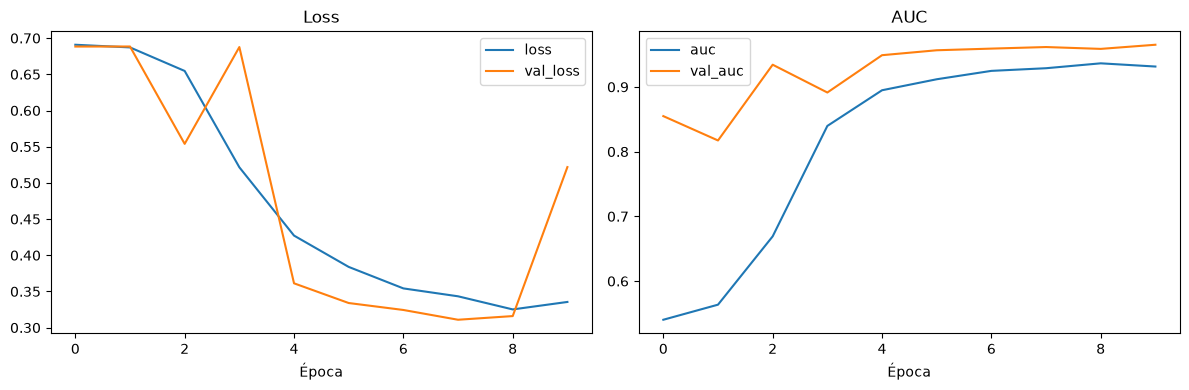

In [11]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

history_df[["loss", "val_loss"]].plot(ax=axes[0])
axes[0].set_title("Loss")
axes[0].set_xlabel("Época")

history_df[["auc", "val_auc"]].plot(ax=axes[1])
axes[1].set_title("AUC")
axes[1].set_xlabel("Época")

plt.tight_layout()
plt.show()


### Inferência no Conjunto de Teste e Métricas Principais

In [12]:
test_metrics = model.evaluate(test_ds, return_dict=True)
test_metrics


20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 247ms/step - accuracy: 0.7869 - auc: 0.8745 - loss: 0.5093 - precision: 0.9079 - recall: 0.7333


{'accuracy': 0.7868589758872986,
 'auc': 0.8744904398918152,
 'loss': 0.5092807412147522,
 'precision': 0.9079365134239197,
 'recall': 0.7333333492279053}

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 254ms/step
              precision    recall  f1-score   support

      Normal       0.66      0.88      0.76       234
   Pneumonia       0.91      0.73      0.81       390

    accuracy                           0.79       624
   macro avg       0.79      0.80      0.78       624
weighted avg       0.82      0.79      0.79       624



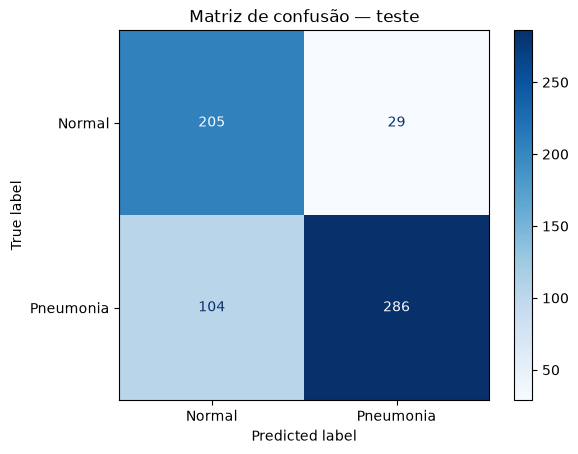

In [13]:
y_true = test_df["label"].to_numpy()
y_score = model.predict(test_ds).ravel()
y_pred = (y_score >= 0.5).astype(int)

print(classification_report(y_true, y_pred, target_names=["Normal", "Pneumonia"]))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Normal", "Pneumonia"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusão — teste")
plt.show()


### Inspeção Visual das Previsões

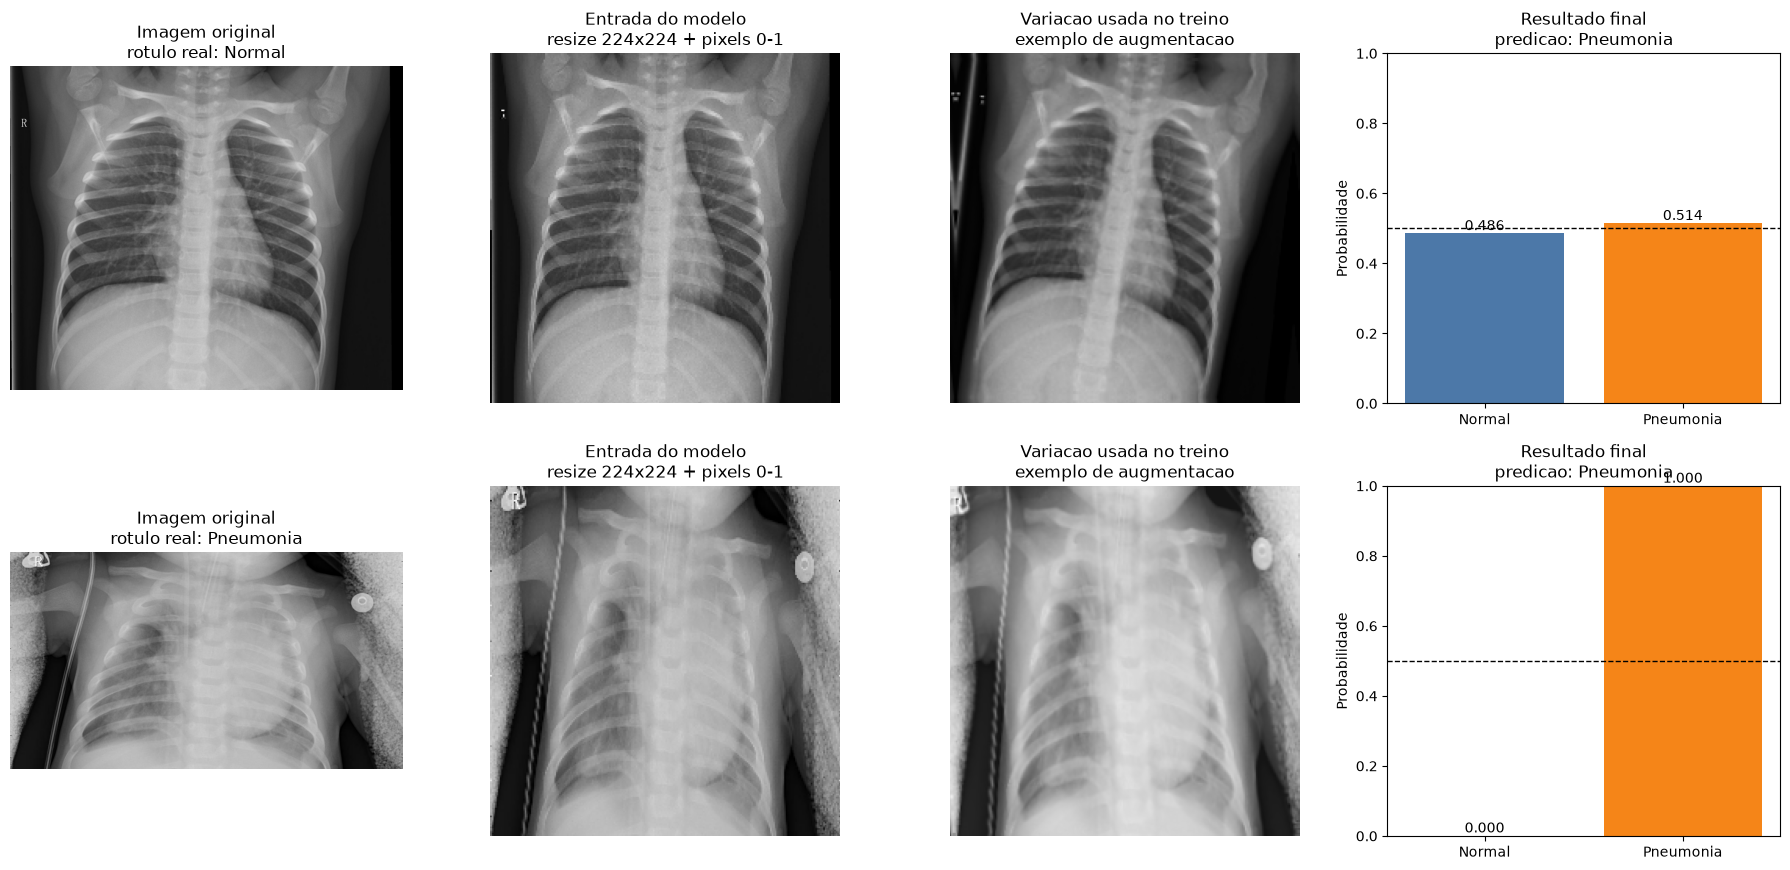

In [14]:
def load_image_for_display(path):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.cast(image, tf.float32) / 255.0
    return image


def make_display_augmentation():
    layers = [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.03),
        tf.keras.layers.RandomZoom(0.05),
        tf.keras.layers.RandomContrast(0.10),
    ]
    if hasattr(tf.keras.layers, "RandomBrightness"):
        try:
            layers.append(tf.keras.layers.RandomBrightness(0.08, value_range=(0, 1)))
        except TypeError:
            layers.append(tf.keras.layers.RandomBrightness(0.08))
    return tf.keras.Sequential(layers, name="augmentacao_visualizacao")


visual_augmentation = make_display_augmentation()

results_df = test_df.copy().reset_index(drop=True)
results_df["true_label"] = y_true
results_df["pneumonia_score"] = y_score
results_df["pred_label"] = y_pred
results_df["normal_score"] = 1.0 - results_df["pneumonia_score"]
results_df["confidence"] = np.maximum(
    results_df["normal_score"], results_df["pneumonia_score"]
)
results_df["is_error"] = results_df["true_label"] != results_df["pred_label"]

if np.nanmax(np.abs(y_score - 0.5)) < 0.01:
    print(
        "Aviso: as probabilidades estao praticamente em 0.5 para todas as imagens. "
        "Isso normalmente indica que a celula de treinamento ainda nao foi executada nesta sessao "
        "ou que o modelo nao aprendeu separacao util. Execute as celulas de treino antes desta visualizacao."
    )

selected_examples = []

normal_as_pneumonia = results_df[
    (results_df["true_label"] == 0) & (results_df["pred_label"] == 1)
].copy()

if not normal_as_pneumonia.empty:
    normal_as_pneumonia["distance_to_threshold"] = (
        normal_as_pneumonia["pneumonia_score"] - 0.50
    ).abs()
    selected_examples.append(
        normal_as_pneumonia.sort_values("distance_to_threshold").iloc[0]
    )

remaining_df = results_df.drop(
    index=[example.name for example in selected_examples], errors="ignore"
)

# Preferimos um exemplo de pneumonia corretamente identificado para contrastar com o falso positivo.
pneumonia_correct = remaining_df[
    (remaining_df["true_label"] == 1) & (remaining_df["pred_label"] == 1)
].copy()

if not pneumonia_correct.empty:
    selected_examples.append(
        pneumonia_correct.sort_values("confidence", ascending=False).iloc[0]
    )
elif len(selected_examples) < 2:
    selected_examples.append(
        remaining_df.sort_values("confidence", ascending=False).iloc[0]
    )

if len(selected_examples) < 2:
    extra_examples = remaining_df.drop(
        index=[example.name for example in selected_examples], errors="ignore"
    )
    selected_examples.extend(
        extra_examples.sort_values("confidence", ascending=False)
        .head(2 - len(selected_examples))
        .itertuples()
    )

fig, axes = plt.subplots(
    len(selected_examples), 4, figsize=(18, 4.4 * len(selected_examples))
)
if len(selected_examples) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_index, example in enumerate(selected_examples):
    if not isinstance(example, pd.Series):
        example = pd.Series(example._asdict()).drop("Index")

    original_image = load_image_for_display(example["path"])
    model_image = tf.image.resize(original_image, IMG_SIZE)
    augmented_image = visual_augmentation(
        tf.expand_dims(model_image, axis=0), training=True
    )[0]

    true_name = class_names[int(example["true_label"])]
    pred_name = class_names[int(example["pred_label"])]
    normal_score = float(example["normal_score"])
    pneumonia_score = float(example["pneumonia_score"])

    axes[row_index, 0].imshow(original_image.numpy(), cmap="gray")
    axes[row_index, 0].set_title(f"Imagem original\nrotulo real: {true_name}")
    axes[row_index, 0].axis("off")

    axes[row_index, 1].imshow(model_image.numpy(), cmap="gray")
    axes[row_index, 1].set_title("Entrada do modelo\nresize 224x224 + pixels 0-1")
    axes[row_index, 1].axis("off")

    axes[row_index, 2].imshow(
        tf.clip_by_value(augmented_image, 0, 1).numpy(), cmap="gray"
    )
    axes[row_index, 2].set_title("Variacao usada no treino\nexemplo de augmentacao")
    axes[row_index, 2].axis("off")

    axes[row_index, 3].bar(
        ["Normal", "Pneumonia"],
        [normal_score, pneumonia_score],
        color=["#4C78A8", "#F58518"],
    )
    axes[row_index, 3].axhline(0.50, color="black", linestyle="--", linewidth=1)
    axes[row_index, 3].set_ylim(0, 1)
    axes[row_index, 3].set_ylabel("Probabilidade")
    axes[row_index, 3].set_title(f"Resultado final\npredicao: {pred_name}")
    axes[row_index, 3].bar_label(axes[row_index, 3].containers[0], fmt="%.3f")

plt.tight_layout()
plt.show()


### Inspeção Visual no Conjunto de Teste

Imagens de teste usadas como origem de augmentacao: 0


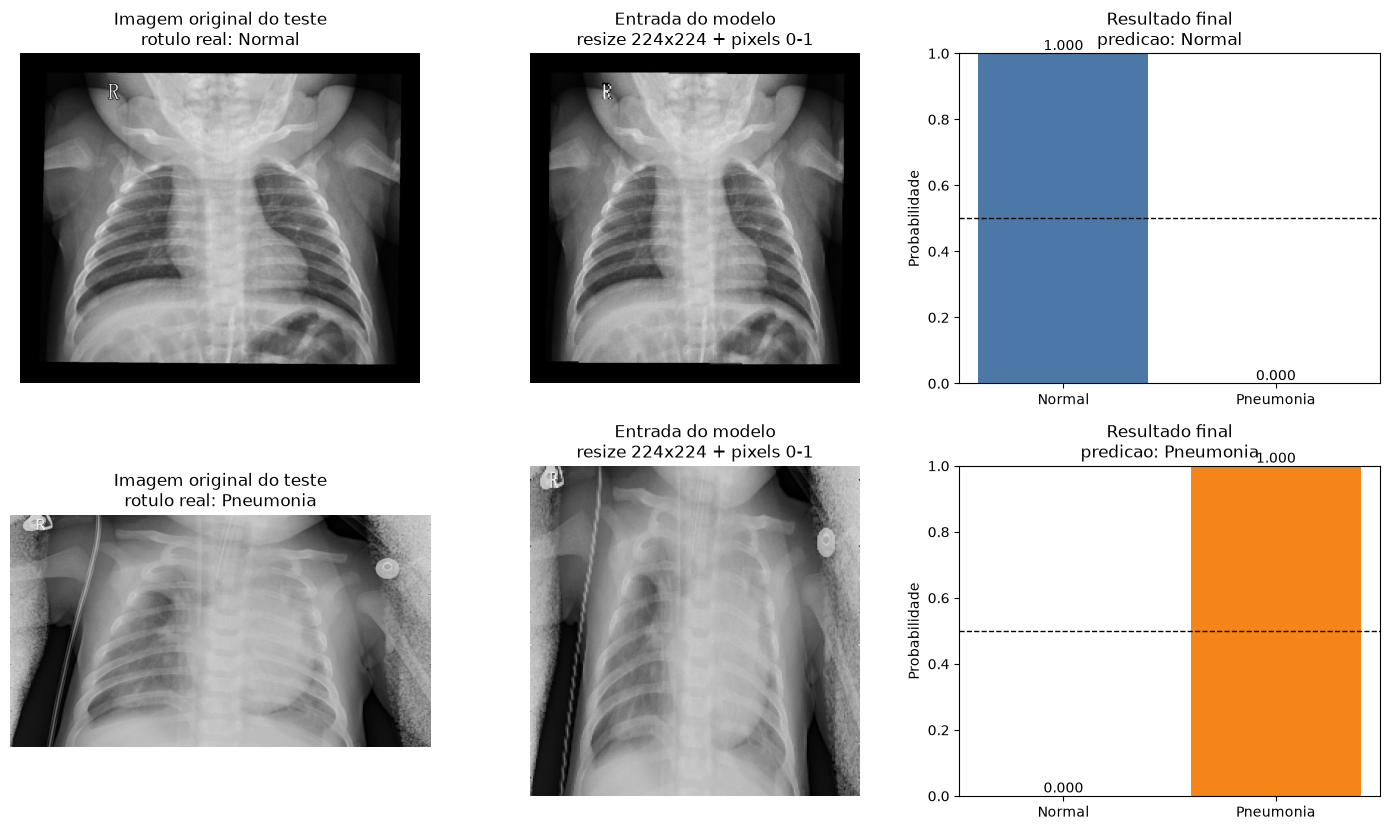

In [15]:
test_only_examples_df = test_df.copy().reset_index(drop=True)
test_only_examples_df["true_label"] = y_true
test_only_examples_df["pneumonia_score"] = y_score
test_only_examples_df["pred_label"] = y_pred
test_only_examples_df["normal_score"] = 1.0 - test_only_examples_df["pneumonia_score"]
test_only_examples_df["confidence"] = np.maximum(
    test_only_examples_df["normal_score"],
    test_only_examples_df["pneumonia_score"],
)

augmented_manifest = AUGMENTED_DIR / "manifest.csv"
if augmented_manifest.exists():
    augmented_sources = set(pd.read_csv(augmented_manifest)["source_path"].astype(str))
else:
    augmented_sources = set()

test_only_examples_df["used_as_augmentation_source"] = test_only_examples_df[
    "path"
].isin(augmented_sources)
print(
    "Imagens de teste usadas como origem de augmentacao:",
    int(test_only_examples_df["used_as_augmentation_source"].sum()),
)

# Escolhe dois exemplos reais do teste: um normal e um pneumonia, quando existirem.
selected_examples = []
for label in [0, 1]:
    candidates = test_only_examples_df[
        (test_only_examples_df["true_label"] == label)
        & (~test_only_examples_df["used_as_augmentation_source"])
    ].copy()
    if not candidates.empty:
        selected_examples.append(
            candidates.sort_values("confidence", ascending=False).iloc[0]
        )

if len(selected_examples) < 2:
    extra_candidates = test_only_examples_df[
        ~test_only_examples_df.index.isin(
            [example.name for example in selected_examples]
        )
        & (~test_only_examples_df["used_as_augmentation_source"])
    ].copy()
    selected_examples.extend(
        extra_candidates.sort_values("confidence", ascending=False)
        .head(2 - len(selected_examples))
        .itertuples()
    )

fig, axes = plt.subplots(
    len(selected_examples), 3, figsize=(14, 4.2 * len(selected_examples))
)
if len(selected_examples) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_index, example in enumerate(selected_examples):
    if not isinstance(example, pd.Series):
        example = pd.Series(example._asdict()).drop("Index")

    original_image = load_image_for_display(example["path"])
    model_image = tf.image.resize(original_image, IMG_SIZE)

    true_name = class_names[int(example["true_label"])]
    pred_name = class_names[int(example["pred_label"])]
    normal_score = float(example["normal_score"])
    pneumonia_score = float(example["pneumonia_score"])

    axes[row_index, 0].imshow(original_image.numpy(), cmap="gray")
    axes[row_index, 0].set_title(f"Imagem original do teste\nrotulo real: {true_name}")
    axes[row_index, 0].axis("off")

    axes[row_index, 1].imshow(model_image.numpy(), cmap="gray")
    axes[row_index, 1].set_title("Entrada do modelo\nresize 224x224 + pixels 0-1")
    axes[row_index, 1].axis("off")

    axes[row_index, 2].bar(
        ["Normal", "Pneumonia"],
        [normal_score, pneumonia_score],
        color=["#4C78A8", "#F58518"],
    )
    axes[row_index, 2].axhline(0.50, color="black", linestyle="--", linewidth=1)
    axes[row_index, 2].set_ylim(0, 1)
    axes[row_index, 2].set_ylabel("Probabilidade")
    axes[row_index, 2].set_title(f"Resultado final\npredicao: {pred_name}")
    axes[row_index, 2].bar_label(axes[row_index, 2].containers[0], fmt="%.3f")

plt.tight_layout()
plt.show()
